# FROG PROJECT - Pressure with Random Forest Regressor

# Settings

In [3]:
USE_BANDPASS = 1
window_size_seconds = 1.25 
USE_NOTCH = 1
USE_ENVELOPE = 0
USE_KALMAN = 0
USE_HILBERT = 1
USE_ZSCORE = 0 
USE_SCALING = 1 
USE_TKEO = 0
USE_NORMALIZATION = 0
HOP_SECONDS = 0.2

user = 300

# USE_ALIGNZERO_GLOBAL = Substract the mean to each channel
# USE_ALIGNZERO_LOCAL 
# USE_OFFSET = Generate more windows with offset
# offset 
# USE_BANDPASS = Filter with bandpass (window by window)
# USE_ZSCORE = Filter with zscore (window by window)
# USE_SCALING = Use feature scaling

print("Settings updated")

Settings updated


# Get data
## Train data

In [4]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict

sampling_rate = 250  # Hz
samples_per_window = int(window_size_seconds * sampling_rate)
all_windowed_data = []

# File paths
emg_dir = fr"C:\Quick_Disk\OpenBCI_user_data\emg_data_Frog\Participant_{user}\Pressure_data_user_{user}.csv"
timestamp_dir = fr"C:\Quick_Disk\ProjectFrog_EMG\Pressure_Classifier\Timestamps\Timestamps_pressure_user_{user}.csv"

# Load data
emg_df = pd.read_csv(emg_dir, sep='\t')  
timestamp_df = pd.read_csv(timestamp_dir, sep=',')  

# Convert timestamps to numeric (float)
emg_timestamps = pd.to_numeric(emg_df.iloc[:, 22], errors='coerce').values
labels = timestamp_df.iloc[:, 0].values
time_stamps = pd.to_numeric(timestamp_df.iloc[:, 1], errors='coerce').values

# Container for all windows from this user
windowed_data = defaultdict(list)

hop_samples = int(HOP_SECONDS * sampling_rate)

for label, ts in zip(labels, time_stamps):
    # Find index in EMG data closest to timestamp ts
    idx = np.argmin(np.abs(emg_timestamps - ts))
    
    """ one window impementation:
    if idx + samples_per_window <= len(emg_df):
        window_df = emg_df.iloc[idx:idx + samples_per_window, 1:4]  # columns 2,3,4 (index 1,2,3)
        window_array = window_df.to_numpy()
        windowed_data[label].append(window_array)
     else:
        print(f"Not enough samples after timestamp {ts} for label {label}, skipping window.")"""

    # Take several samples per window ---------------------------------------------
    end_limit = idx + samples_per_window
    start = idx
    while start <= min(end_limit, len(emg_df) - samples_per_window):
        window = emg_df.iloc[start:start + samples_per_window, 1:4].to_numpy()
        windowed_data[label].append(window)
        start += hop_samples
    # -----------------------------------------------------------------------------
   
all_windowed_data.append(windowed_data)

# Print summary
print(f"Acquired data for user_{user}")
for label, windows in windowed_data.items():
    print(f"  Class '{label}': {len(windows)} windows")


Acquired data for user_300
  Class 'l0': 70 windows
  Class 'l50': 70 windows
  Class 'l100': 70 windows
  Class 'f0': 70 windows
  Class 'f50': 70 windows
  Class 'f100': 70 windows
  Class 'r0': 70 windows
  Class 'r50': 70 windows
  Class 'r100': 70 windows


# Process windows


## Filter windows

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt, iirnotch, hilbert, find_peaks
from pykalman import KalmanFilter

def bandpass_filter(data, lowcut=5.0, highcut=120.0, fs=sampling_rate, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def high_pass_filter(signal, cutoff=0.1, fs=sampling_rate, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

def notch_filter(signal, freq=50.0, fs=sampling_rate, quality=30):
    nyquist = 0.5 * fs
    norm_freq = freq / nyquist
    b, a = iirnotch(norm_freq, quality)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

def compute_envelope(signal, fs=250, cutoff=5.0):
    rectified = np.abs(signal)
    b, a = butter(4, cutoff / (0.5 * fs), btype='low')
    envelope = filtfilt(b, a, rectified)
    return envelope

def compute_envelope_peaks(signal, min_peak_distance=10):
    # Find peaks
    peaks, _ = find_peaks(signal, distance=min_peak_distance)

    if len(peaks) < 2:
        # If not enough peaks, fallback to rectified signal or zeros
        print("Not enough peaks to compute envelope. Returning zeros.")
        return np.zeros_like(signal)

    # Extract peak values
    peak_values = signal[peaks]

    # Interpolate envelope
    envelope = np.interp(np.arange(len(signal)), peaks, peak_values)

    return envelope

def tkeo(signal):
    # Teager-Kaiser Energy Operator 
    output = np.zeros_like(signal)
    for i in range(1, len(signal) - 1):
        output[i] = signal[i]**2 - signal[i - 1] * signal[i + 1]  
    return output 

def kalman(signal):
    signal = signal.reshape(-1, 1)  # reshape to (n_samples, n_dim)
    kf = KalmanFilter(transition_matrices=[1],
                  observation_matrices=[1],
                  initial_state_mean=0,
                  observation_covariance=0.01,
                  transition_covariance=1e-5)

    state_means, _ = kf.filter(signal.reshape(-1, 1))

    return state_means.flatten()

def hilbert_envelope(signal):
    analytic = hilbert(signal)
    envelope = np.abs(analytic)
    return envelope

def normalization_max_val(signal, max_val):
    return signal / max_val if max_val != 0 else signal

def maximum_absolute_value(windowed_data):
    max_vals = np.zeros(3)
    for class_label, windows in windowed_data.items():
        for window in windows:
            abs_window = np.abs(window)
            max_vals = np.maximum(max_vals, abs_window.max(axis=0))
    return max_vals.tolist()

def filter_dataset(dataset):
    filtered_dataset = {}

    for class_label, windows in dataset.items():
        if not windows:
            print(f"No windows for class '{class_label}', skipping filter.")
            continue

        fwindows = []
        for window in windows:
            one_window = window.copy()
            for i in range(window.shape[1]):
                if i in [0, 1, 2]:  
                    if USE_NOTCH == 1:
                        one_window[:, i] = notch_filter(one_window[:, i])

                    if USE_BANDPASS == 1:
                        one_window[:, i] = bandpass_filter(one_window[:, i])

                    if USE_HILBERT == 1:
                        one_window[:, i] = hilbert_envelope(one_window[:, i])

                    if USE_KALMAN == 1:
                        one_window[:, i] = kalman(one_window[:, i])
                        print("Applied Kalman filter")

                    if USE_TKEO == 1:
                        one_window[:, i] = tkeo(one_window[:, i])      

                    if USE_ENVELOPE == 1:
                        one_window[:, i] = compute_envelope(one_window[:, i])

                    if USE_ZSCORE == 1:
                        mean = one_window[:, i].mean()
                        std = one_window[:, i].std()
                        if std == 0:
                            std = 1
                        one_window[:, i] = (one_window[:, i] - mean) / std

            fwindows.append(one_window)

        filtered_dataset[class_label] = fwindows

    return filtered_dataset


def normalize_filtered_data(filtered_data_list):
    # Combine all data across users to find global max values
    combined_data = {}
    for user_data in filtered_data_list:
        for class_label, windows in user_data.items():
            if class_label not in combined_data:
                combined_data[class_label] = []
            combined_data[class_label].extend(windows)

    max_vals = maximum_absolute_value(combined_data)
    print(f"Global maximum absolute values: {max_vals}")

    # Now normalize
    for user_data in filtered_data_list:
        for class_label, windows in user_data.items():
            for window in windows:
                for i in range(window.shape[1]):
                    if i in [0, 1, 2]:
                        window[:, i] = normalization_max_val(window[:, i], max_vals[i])

    return filtered_data_list

filtered = []
for i, dataset in enumerate(all_windowed_data):
    print(f"\n--- Filtering train set for user_{i + 1} ---")
    user_filtered = filter_dataset(dataset)
    filtered.append(user_filtered)
    print("Completed")

if USE_NORMALIZATION == 1:
    print("\n--- Applying final normalization across all users ---")
    filtered = normalize_filtered_data(filtered)




--- Filtering train set for user_1 ---
Completed


## Features

In [6]:
import numpy as np
import pandas as pd
import pywt

# -------------- Feature functions 
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def zero_crossings(signal):
    signs = np.signbit(signal)
    return np.sum(signs[1:] != signs[:-1])

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def mav(signal):
    return np.mean(np.abs(signal))

def iav(signal):
    return np.sum(np.abs(signal))

def rms_signed_difference(signal):
    mean_val = np.mean(signal)
    diff = signal - mean_val
    return np.sqrt(np.mean(diff**2))

def mean_frequency(signal, fs=250):
    # Compute FFT
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    fft_vals = np.abs(np.fft.rfft(signal))
    power = fft_vals ** 2
    if np.sum(power) == 0:
        return 0
    mf = np.sum(freqs * power) / np.sum(power)
    return mf

def wavelet_features(signal, wavelet='db4', level=3):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    features = []
    for c in coeffs:
        energy = np.sum(np.square(c))
        std = np.std(c)
        features.extend([energy, std])
    return features

# -------------------

def parse_pressure_label(label):
    """
    Convert a label like 'l50' into a [left, right, front] pressure vector.
    
    Args:
        label (str): One of 'lXX', 'rXX', or 'fXX', where XX is the pressure (0–100)
    
    Returns:
        List[int]: [left_pressure, right_pressure, front_pressure]
    """
    pressures = {'l': 0, 'f': 0, 'r': 0}
    side = label[0]       # 'l', 'r', or 'f'
    value = int(label[1:])  # e.g., 25 or 100
    pressures[side] = value
    return [pressures['l'], pressures['f'], pressures['r']]


channels = ['ch_1', 'ch_2', 'ch_3']
feature_names = ['RMS', 'RMS_SD', 'ZC', 'WL', 'MAV', 'STD', 'VAR', 'IAV', 'MF']
#wavelet_feature_names = [f'W_E_L{i}' for i in range(4)] + [f'W_STD_L{i}' for i in range(4)]
#feature_names = feature_names + wavelet_feature_names

def extract_features(filtered_data_list):
    features = []
    targets = []

    for user_data in filtered_data_list:
        for label in user_data.keys():  # <-- dynamically get labels here
            for window in user_data.get(label, []):
                feats = []
                for ch_idx in range(len(channels)):
                    ch_signal = window[:, ch_idx]
                    feats.append(rms(ch_signal))
                    feats.append(rms_signed_difference(ch_signal))
                    feats.append(zero_crossings(ch_signal))
                    feats.append(waveform_length(ch_signal))
                    feats.append(mav(ch_signal))
                    feats.append(np.std(ch_signal))
                    feats.append(np.var(ch_signal))
                    feats.append(iav(ch_signal))
                    feats.append(mean_frequency(ch_signal))
                    # feats.extend(wavelet_features(ch_signal, level=3))

                features.append(feats)
                targets.append(parse_pressure_label(label))

    cols = [f"{ch}_{feat}" for ch in channels for feat in feature_names]
    X = pd.DataFrame(features, columns=cols)
    y = pd.DataFrame(targets, columns=["left", "front", "right"])
    return X, y


# Extract features for train and test
X, y = extract_features(filtered)

print("--- Train:")
print(X.head())
print(y)


--- Train:
   ch_1_RMS  ch_1_RMS_SD  ch_1_ZC     ch_1_WL  ch_1_MAV  ch_1_STD   ch_1_VAR  \
0  8.190297     3.971086        0  869.833994  7.163200  3.971086  15.769528   
1  8.244782     3.903965        0  865.463734  7.261920  3.903965  15.240944   
2  8.773055     4.179536        0  912.654522  7.713493  4.179536  17.468520   
3  8.412492     3.827341        0  838.899955  7.491427  3.827341  14.648542   
4  8.159632     3.563423        0  796.375302  7.340410  3.563423  12.697986   

      ch_1_IAV   ch_1_MF  ch_2_RMS  ...   ch_2_MF  ch_3_RMS  ch_3_RMS_SD  \
0  2234.918337  3.944941  6.444795  ...  4.718179  6.824328     3.440428   
1  2265.719107  3.800136  6.178913  ...  4.982220  6.504692     3.083920   
2  2406.609715  3.880625  6.071240  ...  4.975095  7.545199     4.056967   
3  2337.325192  3.606804  6.195476  ...  4.678574  7.396352     4.007498   
4  2290.207851  3.350838  6.503379  ...  4.769413  7.227793     3.970547   

   ch_3_ZC     ch_3_WL  ch_3_MAV  ch_3_STD   ch_3_V

# Classification

## Random Forest Tree

Fitting 3 folds for each of 12 candidates, totalling 36 fits

--- Best Parameters ---
{'regressor__estimator__max_depth': None, 'regressor__estimator__min_samples_split': 2, 'regressor__estimator__n_estimators': 100}

--- R² Scores (per output) ---
[0.45442593 0.58770921 0.75536361]

--- RMSE (per output) ---
[24.17733755 20.95109574 16.62303813]


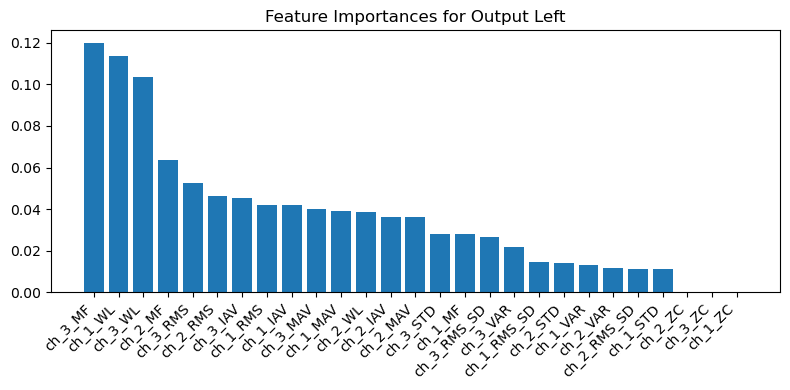

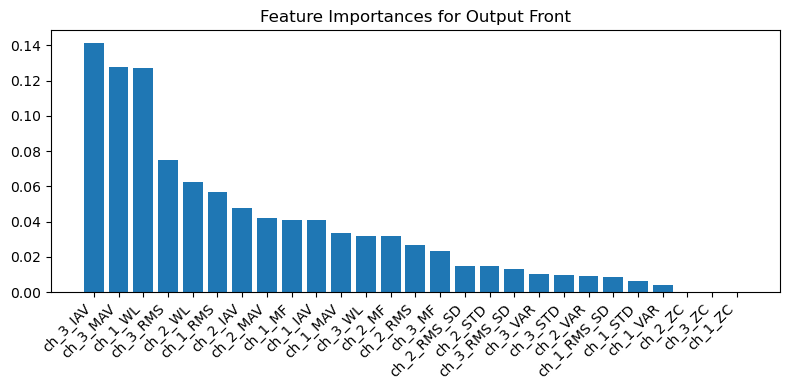

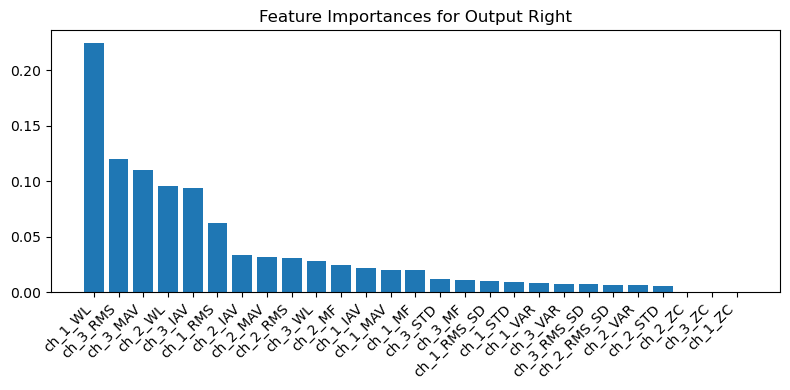

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import joblib
import matplotlib.pyplot as plt

#---------------------------------------------------------------------------------
# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#---------------------------------------------------------------------------------
# Define pipeline steps conditionally
steps = []

if USE_SCALING:
    steps.append(('scaler', StandardScaler()))

steps.append(('regressor', MultiOutputRegressor(RandomForestRegressor(random_state=42))))

pipeline = Pipeline(steps)

param_grid = {}

param_grid.update({
    'regressor__estimator__n_estimators': [50, 100],
    'regressor__estimator__max_depth': [None, 10, 20],
    'regressor__estimator__min_samples_split': [2, 5],
})

# Grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

#---------------------------------------------------------------------------------
# Fit the model
grid_search.fit(X_train, y_train)

# Predict
y_pred = grid_search.predict(X_test)

# Evaluation
print("\n--- Best Parameters ---")
print(grid_search.best_params_)

print("\n--- R² Scores (per output) ---")
print(r2_score(y_test, y_pred, multioutput='raw_values'))

print("\n--- RMSE (per output) ---")
print(np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values')))

# Export for real-time use
best_pipeline = grid_search.best_estimator_

# Save the pipeline (scaler + regressor)
joblib.dump(best_pipeline, f'models/Pressure_regressor_user_frog_{user}.joblib')

# -------- Show feature importance per channel
# Get the fitted MultiOutputRegressor from the best pipeline
multi_output_rf = grid_search.best_estimator_.named_steps['regressor']

# Get feature names if you have them, else use generic
feature_names = X.columns if hasattr(X, 'columns') else [f'feat_{i}' for i in range(X.shape[1])]

# Loop through each regressor (one per output)
for i, reg in enumerate(multi_output_rf.estimators_):
    importances = reg.feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]

    name = ""
    if i == 0:
        name = "Left"
    elif i == 1:
        name = "Front"
    elif i == 2:
        name = "Right" 
    plt.figure(figsize=(8, 4))
    plt.title(f"Feature Importances for Output {name}")
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[j] for j in indices], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
